# Week 4 Day 4
This week we've discussed measures of centering and variation. Today, we'll discuss measures of relationship between datasets: *correlation* and *covariance*.



In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Motivation 
Consider the `wine` dataset from GitHub: [click here for Datasets folder](https://github.com/garrett-kepler/Math-300----Mathematical-Computing/tree/main/Datasets)


In [2]:
wine = pd.read_csv(r"https://raw.githubusercontent.com/garrett-kepler/Math-300----Mathematical-Computing/refs/heads/main/Datasets/wine.csv")

In [3]:
wine

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,3,13.71,5.65,2.45,20.5,95,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740
174,3,13.40,3.91,2.48,23.0,102,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750
175,3,13.27,4.28,2.26,20.0,120,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835
176,3,13.17,2.59,2.37,20.0,120,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840


We have a lot of wines with a lot of features. Looking solely at color intensity and hue:

In [4]:
colors = wine['Color intensity']
hue = wine['Hue']

Text(0, 0.5, 'Hue')

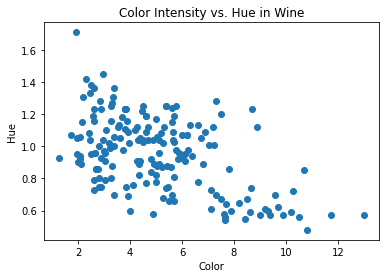

In [5]:
plt.scatter(colors, hue)
plt.title('Color Intensity vs. Hue in Wine')
plt.xlabel('Color')
plt.ylabel('Hue')

Are the two features related? If color intensity increases, what happens to hue? How do we quantify this?

### Covariance

Covariance of two datasets $X$ and $Y$ formulaically is:
$$
\mathrm{Cov}(X,Y)
=
\frac{
\sum_{i=1}^{n}
(x_i-\bar{x})
(y_i-\bar{y})
}
{n-1}
$$

where

- $x_i$ = data point from X
- $y_i$ = data point from Y
- $\bar{x}$ = mean of X
- $\bar{y}$ = mean of Y



Covariance measures whether two variables move together.

If

- X increases
- Y increases

the covariance is positive.

If

- X increases
- Y decreases

the covariance is negative.

Step 1

Subtract each observation from its mean: 
$$ x_i - \bar{x} $$

$$


What we are asking is: "how far away from the mean have you deviated?"

Step 2

Multiply the deviations together:

$$(x_i - \bar{x})(y_i - \bar{y})
$$

Positive × Positive = Positive

Negative × Negative = Positive

Positive × Negative = Negative

---

To compute the covariance:

In [6]:
cov = np.cov(colors, hue) # np.cov(first data, second data)

print(cov)

[[ 5.37444938 -0.2765058 ]
 [-0.2765058   0.05224496]]


In [7]:
# note that cov(colors, colors) is just variance of colors

np.var(colors)

5.344255847629093

In [10]:
hue.describe()

count    178.000000
mean       0.957449
std        0.228572
min        0.480000
25%        0.782500
50%        0.965000
75%        1.120000
max        1.710000
Name: Hue, dtype: float64

Positive covariance

```
X increases
Y increases
```

or

```
X decreases
Y decreases
```

Negative covariance

```
X increases
Y decreases
```

Zero covariance

No overall linear relationship.

---

Changing units changes covariance.

Therefore

> Covariance is **not standardized.**

Correlation fixes this.

---

# Correlation Formula

$$
r
=
\frac{
\sum
(x_i-\bar{x})
(y_i-\bar{y})
}
{
\sqrt{
\sum(x_i-\bar{x})^2
}
\sqrt{
\sum(y_i-\bar{y})^2
}
}
$$


Correlation measures the strength of a linear relationship. Unlike covariance, it always lies between -1 and 1. $r = 1$ signifiges a perfect positive relationship. $r = -1$, a perfect negative relationship. $r=0$ implies no linear relationship.


In [11]:
corr = np.corrcoef(colors, hue)

print(corr)

[[ 1.         -0.52181319]
 [-0.52181319  1.        ]]


A high correlation does **not** prove that one variable causes the other.

In [13]:
wine.corr()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
Class,1.000000,-0.328222,0.437776,-0.049643,0.517859,-0.209179,-0.719163,-0.847498,0.489109,-0.499130,0.265668,-0.617369,-0.788230,-0.633717
Alcohol,-0.328222,1.000000,0.094397,0.211545,-0.310235,0.270798,0.289101,0.236815,-0.155929,0.136698,0.546364,-0.071747,0.072343,0.643720
Malic acid,0.437776,0.094397,1.000000,0.164045,0.288500,-0.054575,-0.335167,-0.411007,0.292977,-0.220746,0.248985,-0.561296,-0.368710,-0.192011
Ash,-0.049643,0.211545,0.164045,1.000000,0.443367,0.286587,0.128980,0.115077,0.186230,0.009652,0.258887,-0.074667,0.003911,0.223626
Alcalinity of ash,0.517859,-0.310235,0.288500,0.443367,1.000000,-0.083333,-0.321113,-0.351370,0.361922,-0.197327,0.018732,-0.273955,-0.276769,-0.440597
Magnesium,-0.209179,0.270798,-0.054575,0.286587,-0.083333,1.000000,0.214401,0.195784,-0.256294,0.236441,0.199950,0.055398,0.066004,0.393351
Total phenols,-0.719163,0.289101,-0.335167,0.128980,-0.321113,0.214401,1.000000,0.864564,-0.449935,0.612413,-0.055136,0.433681,0.699949,0.498115
Flavanoids,-0.847498,0.236815,-0.411007,0.115077,-0.351370,0.195784,0.864564,1.000000,-0.537900,0.652692,-0.172379,0.543479,0.787194,0.494193
Nonflavanoid phenols,0.489109,-0.155929,0.292977,0.186230,0.361922,-0.256294,-0.449935,-0.537900,1.000000,-0.365845,0.139057,-0.262640,-0.503270,-0.311385
Proanthocyanins,-0.499130,0.136698,-0.220746,0.009652,-0.197327,0.236441,0.612413,0.652692,-0.365845,1.000000,-0.025250,0.295544,0.519067,0.330417


In [15]:
wine[['Class','Alcohol']]

,Class,Alcohol
0,1,14.23
1,1,13.20
2,1,13.16
3,1,14.37
4,1,13.24
...,...,...
173,3,13.71
174,3,13.40
175,3,13.27
176,3,13.17
